In [12]:
import pandas as pd

# Load the CSV
path = "/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Study3.0Pilot/intuitive-feature-pilot3.csv"
df = pd.read_csv(path)

# Select columns starting with p, r, or f 
cols_prf = df.filter(regex=r'^[prf]')



In [ ]:
p_cols = [c for c in df.columns if c.startswith("p")]

def has_non_numeric(series):
    return pd.to_numeric(series, errors="coerce").isna().any() and series.notna().any()

bad_cols = [c for c in p_cols if has_non_numeric(df[c])]

print("Columns with non-numeric values:")
print(bad_cols)
for c in bad_cols:
    bad_vals = df.loc[
        pd.to_numeric(df[c], errors="coerce").isna() & df[c].notna(),
        c
    ].unique()
    
    print(f"\nColumn: {c}")
    print("Non-numeric values:", bad_vals)

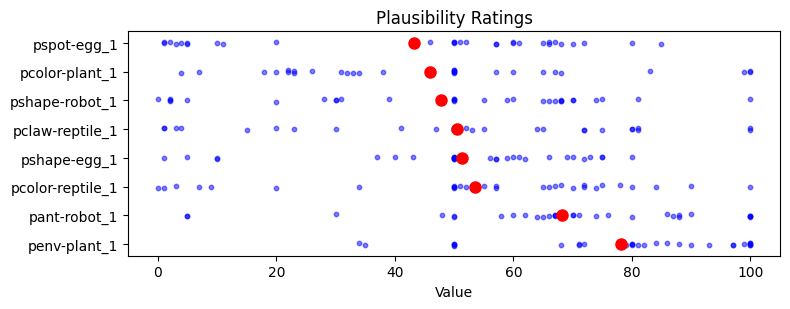

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Select p* columns
p_cols = [c for c in df.columns if c.startswith("p")]

# Remove question-text rows
df_data = df.iloc[2:]

# Convert to numeric
df_p = df_data[p_cols].apply(pd.to_numeric, errors="coerce")

# Sort columns by mean for y-axis ordering
summary_order = df_p.mean().sort_values(ascending=True).index

# Calculate column means
col_means = df_p[summary_order].mean()

fig, ax = plt.subplots(figsize=(8, len(summary_order) * 0.4))

y = np.arange(len(summary_order))

# Plot individual points
for i, col in enumerate(summary_order):
    jitter = (np.random.rand(len(df_p)) - 0.5) * 0.1  # small y jitter
    ax.scatter(df_p[col], i + jitter, color='blue', alpha=0.5, s=10)

# Overlay the mean as a red dot
ax.plot(col_means.values, y, 'o', color='red', markersize=8, label='Mean')

ax.set_yticks(y)
ax.set_yticklabels(summary_order)
ax.set_xlabel("Value")
ax.set_title("Plausibility Ratings")
ax.invert_yaxis()  # lowest mean at the top

plt.tight_layout()
plt.show()

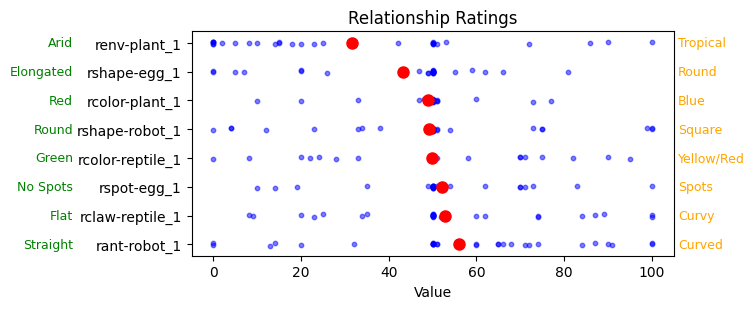

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Select r* columns
r_cols = [c for c in df.columns if c.startswith("r")]

# Remove question-text rows
df_data = df.iloc[2:]

# Convert to numeric
df_r = df_data[r_cols].apply(pd.to_numeric, errors="coerce")

# Sort columns by mean for y-axis ordering
summary_order = df_r.mean().sort_values(ascending=True).index
# Calculate column means
col_means = df_r[summary_order].mean()

fig, ax = plt.subplots(figsize=(8, len(summary_order) * 0.4))

y = np.arange(len(summary_order))

# Plot individual points
for i, col in enumerate(summary_order):
    jitter = (np.random.rand(len(df_r)) - 0.5) * 0.1  # small y jitter
    ax.scatter(df_r[col], i + jitter, color='blue', alpha=0.5, s=10)

# Overlay the mean as a red dot
ax.plot(col_means.values, y, 'o', color='red', markersize=8, label='Mean')

ax.set_yticks(y)
ax.set_yticklabels(summary_order)
ax.set_xlabel("Value")
ax.set_title("Relationship Ratings")
ax.invert_yaxis()  # lowest mean at the top

custom_labels = [
    ("Arid", "Tropical"),
    ("Elongated", "Round"),
    ("Red", "Blue"),
    ("Round", "Square"),
    ('Green', 'Yellow/Red'),
    ('No Spots', 'Spots'),
    ('Flat', 'Curvy'),
    ('Straight', 'Curved'),
]

# Loop through and add text
for i, labels in enumerate(custom_labels):
    low_label, high_label = labels
    ax.text(-32, i, low_label, va='center', ha='right', color='green', fontsize=9)
    ax.text(106, i, high_label, va='center', ha='left', color='orange', fontsize=9)

plt.tight_layout()
plt.show()

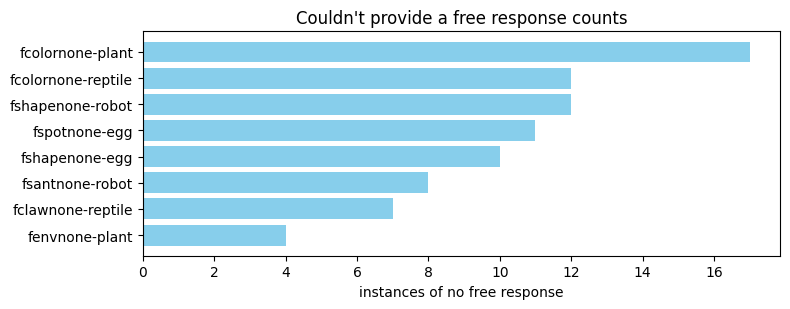

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

f_cols = [c for c in df.columns if c.startswith("f") and 'none' in c.lower()]

# Skip first two rows (question text)
df_data = df.iloc[2:]

# Convert all to string to handle mixed types
df_f = df_data[f_cols].astype(str)

# Count occurrences of 'none' per column
none_counts = (df_f == '1').sum()

# Optional: sort by count ascending for easier plotting
none_counts = none_counts.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, len(f_cols) * 0.4))

y = range(len(none_counts))
ax.barh(y, none_counts.values, color="skyblue")
ax.set_yticks(y)
ax.set_yticklabels(none_counts.index)
ax.set_xlabel("instances of no free response")
ax.set_title("Couldn't provide a free response counts")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Select all f* columns that are **free responses**, ignoring 'none' checkboxes
f_cols = [c for c in df.columns if c.startswith("f")]

# Skip the first two rows (question text)
df_data = df.iloc[2:]

# Convert to string (so everything is comparable)
df_f = df_data[f_cols].astype(str)

# Print free responses per column (ignore 'none' or empty strings)
for col in f_cols:
    # Keep only non-empty, non-'none' entries
    free_responses = df_f[col][~df_f[col].str.lower().isin(['none', '', 'nan'])]
    
    print(f"\nColumn: {col} (total {len(free_responses)})")
    for i, resp in enumerate(free_responses, start=1):
        print(f"{i}. {resp}")


Column: fenv-plant (total 26)
1. So, fertilizer helps plants grow obviously. The tropical setting would probably have more animals/waste that it could feed off of and grow. Whereas the dessert has hardly any life in it for it to feed from.
2. Fertilizer needs are probably different because the types of soil that is present. The soil in each location would probably need to be treated differently depending on which nutrients are naturally present in each environment.
3. the amount of moisture can affect the amount of nutrients the plant can uptake
4. I figure those in arid climates are very dry, so they would need more fertilizer to survive in that climate
5. I would assume that an arid environment contains soil lacking moisture and nutrients when compared to a tropical environment. This would be due to the very dry conditions.
6. I think the most areas are better for the plant becuase they get more water which is what most plants need to survive.
7. Maybe in the desert because the cond